# 69) One-Way ANOVA Nedir?
One-Way ANOVA, **tek bir kategorik değişkene** göre oluşturulmuş 3 veya daha fazla grubun ortalamalarını karşılaştırır. "One-Way" (tek yönlü) ismi, sadece **bir** gruplama faktörü olduğu için — örneğin sadece "Bölge" (Doğu/Batı/Güney/Kuzey), başka bir faktör yok.

## Örnek Senaryo
Farklı ürün kategorilerinin (Mobilya, Teknoloji, Ofis Malzemeleri) ortalama kâr marjı birbirinden farklı mı?" — burada tek gruplama faktörü **Kategori.**

## Hipotezler
- **H0:** $\mu_{Mobilya} = \mu_{Teknoloji} = \mu_{Ofis}$ (üç kategorinin de ortalama kâr marjı eşittir)
- **H1:** En az bir kategori, diğerlerinden farklı bir ortalamaya sahiptir

## F-İstatistiği ve P-Değeri
Konu 65'de gördüğümüz $F = \frac{\text{Gruplar Arası Varyans}}{\text{Grup İçi Varyans}}$ formülü hesaplanır, bu F değeri bir F-dağılımına göre yorumlanır (yeni bir dağılım türü — Z ve t'den farklı, iki farklı serbestlik derecesi gerektirir: biri "gruplar arası," biri "grup içi"), ve p-değeri bulunur.

## Python'da Kullanımı
```python
from scipy import stats
f_istatistigi, p_degeri = stats.f_oneway(grup1, grup2, grup3)
```

## Önemli Hatırlatma
ANOVA'yı uygulamadan önce varsayımları (normallik, varyans homojenliği) kontrol etmek gerekir. Shapiro-Wilk ve Levene testleriyle daha önce yaptığımız gibi.

*****Betimsel Durum*****
Sosyal Medya kanalından gelen müşterilerin ortalama sipariş tutarı: 245.75
Sosyal Medya kanalından gelen müşterilerin harcamalarının standart sapması: 26.65872277510684
Arama Motoru kanalından gelen müşterilerin ortalama sipariş tutarı: 301.25
Arama Motoru kanalından gelen müşterilerin harcamalarının standart sapması: 32.01074038506451
Email kanalından gelen müşterilerin ortalama sipariş tutarı: 248.55
Email kanalından gelen müşterilerin harcamalarının standart sapması: 17.02784484307982
*****Varsayımlar*****
*****Normallik Varsayımı Sonuçları*****
P değeri = 0.2909737610569426, H0 Hipotezi reddedilemez, Sosyal Medya kanalına ait veri normal dağılıyor.
P değeri = 0.5080920643662439, H0 Hipotezi reddedilemez, Arama Motoru kanalına ait veri normal dağılıyor.
P değeri = 0.9891284175143827, H0 Hipotezi reddedilemez, Email kanalına ait veri normal dağılıyor.


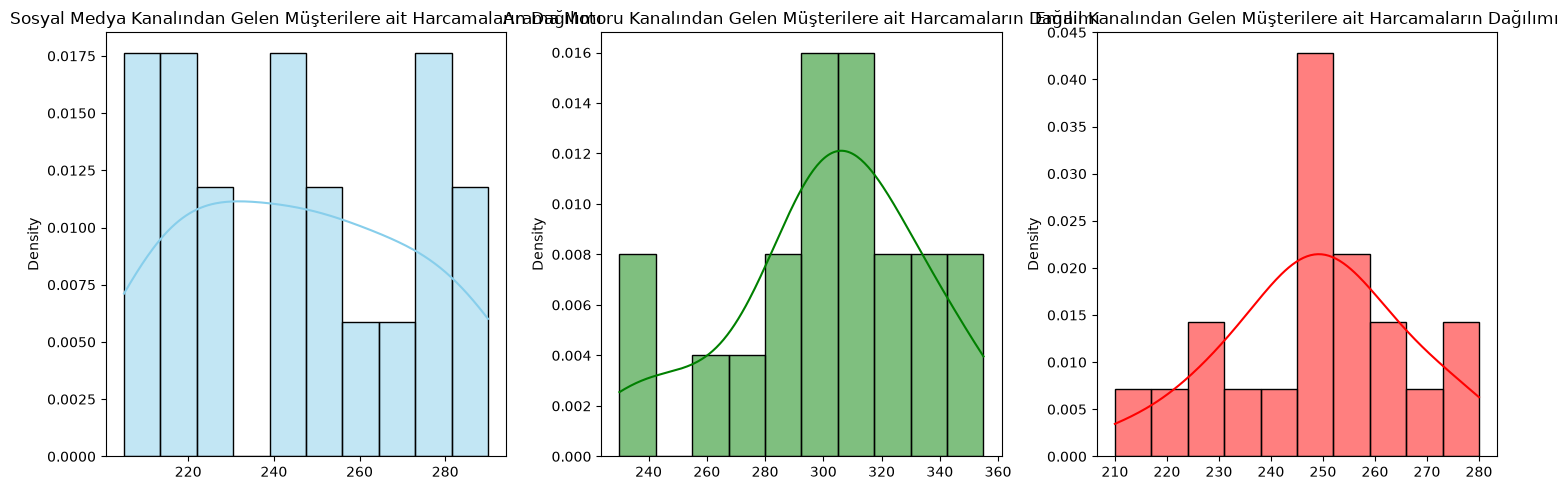

*****Homojenlik Varsayımı*****
***** Tek Yönlü Varyans Analizi *****
F istatistiği: 27.512215955730515
P-değeri: 4.335308477398809e-09
H0 hipotezini reddecek güçlü kanıtlara sahibiz. En az bir grubun ortalaması diğer grupların ortalamasından anlamlı biçimde farklıdır.


In [15]:
### Örnek
# Bir e-ticaret şirketi, üç farklı pazarlama kanalından (Sosyal Medya, Arama Motoru, Email) gelen müşterilerin ortalama sipariş tutarını (TL) karşılaştırmak istiyor.

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# suppress=True -> Bilimsel gösterimi (e'li gösterimi) tamamen kapatır.
# precision=8   -> Virgülden sonra maksimum kaç basamak gösterileceğini belirler.
np.set_printoptions(suppress=True, precision=7)

sosyal_medya = np.array([245, 280, 210, 265, 290, 230, 255, 275, 220, 260, 240, 250, 220, 210, 220, 290, 230, 205, 245, 275])
arama_motoru = np.array([310, 340, 295, 325, 355, 300, 330, 315, 305, 345, 300, 290, 255, 240, 285, 230, 300, 310, 275, 320])
email = np.array([260, 245, 275, 250, 265, 240, 270, 255, 248, 258, 230, 237, 223, 245, 255, 280, 210, 230, 245, 250])

# H0: 3 farklı pazarlama kanalındaki müşterilerin ortalama sipariş tutarları aynıdır.
# H1: En az bir farklı pazarlama kanalı, diğerlerinden farklı bir ortalamaya sahiptir. 

print('*****Betimsel Durum*****')
ort_sosyal_medya = np.mean(sosyal_medya)
std_sosyal_medya = np.std(sosyal_medya)
ort_arama_motoru = np.mean(arama_motoru)
std_arama_motoru = np.std(arama_motoru)
ort_email = np.mean(email)
std_email = np.std(email)
print(f'Sosyal Medya kanalından gelen müşterilerin ortalama sipariş tutarı: {ort_sosyal_medya}')
print(f'Sosyal Medya kanalından gelen müşterilerin harcamalarının standart sapması: {std_sosyal_medya}')
print(f'Arama Motoru kanalından gelen müşterilerin ortalama sipariş tutarı: {ort_arama_motoru}')
print(f'Arama Motoru kanalından gelen müşterilerin harcamalarının standart sapması: {std_arama_motoru}')
print(f'Email kanalından gelen müşterilerin ortalama sipariş tutarı: {ort_email}')
print(f'Email kanalından gelen müşterilerin harcamalarının standart sapması: {std_email}')

print('*****Varsayımlar*****')
# H0: Sosyal medya kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılıyor.
# H1: Sosyal medya kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılmıyor.
normallik_sosyal_medya_p_degeri = stats.shapiro(sosyal_medya).pvalue
# H0: Arama Motoru kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılıyor.
# H1: Arama Motoru kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılmıyor.
normallik_arama_motoru_p_degeri = stats.shapiro(arama_motoru).pvalue
# H0: Enail kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılıyor.
# H1: Email kanalından gelen kullanıcılarının yaptığı harcamalar normal dağılmıyor.
normallik_email_p_degeri = stats.shapiro(email).pvalue

print("*****Normallik Varsayımı Sonuçları*****")
def hipotez_kontrol_edici(kanal:str, pvalue:int, alpha=0.05) -> None:
    if pvalue < alpha:
        print(f"P değeri = {pvalue}, H0 Hipotezi reddedilir, {kanal} kanalına ait veri normal dağılmıyor.")
    else:
        print(f"P değeri = {pvalue}, H0 Hipotezi reddedilemez, {kanal} kanalına ait veri normal dağılıyor.")

hipotez_kontrol_edici(kanal="Sosyal Medya", pvalue=normallik_sosyal_medya_p_degeri)
hipotez_kontrol_edici(kanal="Arama Motoru", pvalue=normallik_arama_motoru_p_degeri)
hipotez_kontrol_edici(kanal="Email", pvalue=normallik_email_p_degeri)

fig, axes = plt.subplots(1,3, figsize=(15,5))

# En soldaki grafik
sns.histplot(sosyal_medya,bins=10, kde=True, color="skyblue", ax=axes[0], stat="density")
axes[0].set_title("Sosyal Medya Kanalından Gelen Müşterilere ait Harcamaların Dağılımı")
sns.histplot(arama_motoru, bins=10, kde=True, color="green", ax=axes[1], stat="density")
axes[1].set_title("Arama Motoru Kanalından Gelen Müşterilere ait Harcamaların Dağılımı")
sns.histplot(email, bins=10, kde=True, color="red", ax=axes[2], stat="density")
axes[2].set_title("Email Kanalından Gelen Müşterilere ait Harcamaların Dağılımı")

plt.tight_layout()
plt.show()

alpha = 0.05

print("*****Homojenlik Varsayımı*****")
# H0: Gruplar arası varyans homojendir.
# H1: Gruplar arası varyans homojen değildir.
if (normallik_sosyal_medya_p_degeri < alpha or normallik_arama_motoru_p_degeri < alpha or normallik_email_p_degeri < alpha):
    levene_p_degeri = stats.levene(sosyal_medya, arama_motoru, email).pvalue
    print(f"Levene Testine ait P-Değeri: {levene_p_degeri}")
    if levene_p_degeri < alpha:
        print("Gruplar arası varyans homojen değil, equal_var parametresi False olarak ayarlanmalıdır.")
    else:
        print("Gruplar arası varyans homojendir. eqaul_var parametresi True olarak ayarlanmalıdır.")
"""
    # NOT: SciPy 1.17.1 sürümünde stats.bartlett() fonksiyonunda bilinen bir 
    # hata var (ValueError: cannot convert float NaN to integer). Bu yüzden 
    # normallik sağlansa bile, güvenilir sonuç almak için Levene testi kullanıldı.     
else:
    bartlett_p_degeri = stats.bartlett(sosyal_medya, arama_motoru, email)[1]
    print(f"Bartlett Testine ait P-Değeri: {bartlett_p_degeri}")
    if bartlett_p_degeri < alpha:
        print("Gruplar arası varyans homojen değil, equal_var parametresi False olarak ayarlanmalıdır.")
    else:
        print("Gruplar arası varyans homojendir. eqaul_var parametresi True olarak ayarlanmalıdır.")
"""

print("***** Tek Yönlü Varyans Analizi *****")
f_degeri, anova_p = stats.f_oneway(sosyal_medya, arama_motoru, email)
print(f"F istatistiği: {f_degeri}")
print(f"P-değeri: {anova_p}")
if anova_p < alpha:
    print("H0 hipotezini reddecek güçlü kanıtlara sahibiz. En az bir grubun ortalaması diğer grupların ortalamasından anlamlı biçimde farklıdır.")
else:
    print("H0 hipotezini reddecek güçlü kanıtlara sahip değiliz. En az bir grubun ortalaması diğer grupların ortalamasıyla aynıdır.")

### Sonuç
Üç farklı pazarlama kanalından (Sosyal Medya, Arama Motoru, Email) gelen müşterilerin ortalama sipariş tutarları arasında istatistiksel olarak anlamlı bir fark olup olmadığını test etmek amacıyla yaptığımız Tek Yönlü ANOVA sonuçlarına göre, en az bir kanalın ortalama sipariş tutarı diğerlerinden anlamlı biçimde farklıdır (F=27.51, p<0.001). Betimsel istatistiklere bakıldığında, Arama Motoru kanalının ortalama sipariş tutarının (301.25 TL) diğer iki kanala (Sosyal Medya: 245.75 TL, Email: 248.55 TL) göre belirgin şekilde yüksek olduğu görülmektedir. Ancak ANOVA testi hangi kanal ya da kanalların birbirinden farklı olduğunu belirtmediği için, bu sorunun cevabı Post-Hoc analizleriyle netleştirilecektir.